## Factibilidad de recomendación por matriz cliente-producto y popularidad (long tail)

## Objetivo

Evaluar la factibilidad de los enfoques de recomendación a partir de las características actuales del dataset de ReActiva.

El análisis contempla:

- densidad y sparsity de la matriz cliente-producto;
- profundidad del historial disponible por cliente;
- cold start de clientes nuevos;
- comportamiento de los clientes inactivos según el umbral de 270 días;
- distribución de popularidad y presencia de long tail;
- cobertura y soporte de las relaciones entre productos;
- estabilidad temporal de la popularidad y de las asociaciones item-item;
- evolución de la información disponible a medida que se acumulan nuevas transacciones;
- necesidad de mecanismos de fallback cuando el historial individual resulta insuficiente.

> **Alcance:** este notebook es exclusivamente diagnóstico. No modifica modelos, lógica de recomendación ni archivos productivos del proyecto.

#### 1) Importaciones de Librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

from reactiva.data.load_data import cargar_datos
from reactiva.features.build_features import add_season

from IPython.display import display, HTML

#### 2) Carga y validación inicial del dataset

In [2]:
df = cargar_datos()

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Clientes únicos: {df['Customer ID'].nunique()}")
print(f"Productos únicos: {df['Item Purchased'].nunique()}")
print(f"Fecha mínima: {pd.to_datetime(df['Purchase Date']).min().date()}")
print(f"Fecha máxima: {pd.to_datetime(df['Purchase Date']).max().date()}")

Filas: 10000
Columnas: 27
Clientes únicos: 3291
Productos únicos: 24
Fecha mínima: 2023-01-01
Fecha máxima: 2024-12-30


#### 3) Matriz cliente-producto y sparsity global

In [3]:
customer_item_matrix = pd.crosstab(
    df["Customer ID"],
    df["Item Purchased"]
)
observed_interactions = (customer_item_matrix.values > 0).sum()
possible_interactions = customer_item_matrix.size
sparsity = 1 - (
    observed_interactions / possible_interactions
)
density = 1 - sparsity
print(f"Clientes: {customer_item_matrix.shape[0]}")
print(f"Productos: {customer_item_matrix.shape[1]}")
print(f"Interacciones posibles: {possible_interactions}")
print(f"Interacciones observadas: {observed_interactions}")
print(f"Sparsity: {sparsity:.4f} ({sparsity * 100:.2f}%)")
print(f"Densidad: {density:.4f} ({density * 100:.2f}%)")

Clientes: 3291
Productos: 24
Interacciones posibles: 78984
Interacciones observadas: 9276
Sparsity: 0.8826 (88.26%)
Densidad: 0.1174 (11.74%)


La matriz cliente-producto presenta una sparsity global de 88,26%, por lo que únicamente el 11,74% de las combinaciones posibles entre clientes y productos cuenta con una interacción observada. Este nivel de dispersión indica que el historial disponible por cliente es limitado respecto del catálogo completo. Sin embargo, la sparsity por sí sola no determina la inviabilidad de un sistema de recomendación, por lo que es necesario complementar este resultado analizando la profundidad de los historiales individuales y el soporte existente entre productos.

#### 4) Profundidad del historial por cliente

In [4]:
customer_history = (
    df.groupby("Customer ID")["Item Purchased"]
    .nunique()
)
# Resumen estadístico
history_summary = (
    customer_history
    .describe()
    .round(2)
    .rename("Valor")
    .reset_index()
    .rename(columns={"index": "Estadística"})
)
# Indicadores principales
history_metrics = pd.DataFrame({
    "Indicador": [
        "1 producto único",
        ">=2 productos únicos",
        ">=3 productos únicos",
        ">=5 productos únicos",
    ],
    "Clientes": [
        int((customer_history == 1).sum()),
        int((customer_history >= 2).sum()),
        int((customer_history >= 3).sum()),
        int((customer_history >= 5).sum()),
    ],
    "Porcentaje": [
        f"{(customer_history == 1).mean() * 100:.2f}%",
        f"{(customer_history >= 2).mean() * 100:.2f}%",
        f"{(customer_history >= 3).mean() * 100:.2f}%",
        f"{(customer_history >= 5).mean() * 100:.2f}%",
    ],
})
display(
    HTML(
        f"""
        <div style="display:flex; gap:40px; align-items:flex-start;">
            <div>
                <h4>Resumen estadístico</h4>
                {history_summary.to_html(index=False)}
            </div>
            <div>
                <h4>Indicadores del historial</h4>
                {history_metrics.to_html(index=False)}
            </div>
        </div>
        """
    )
)

La profundidad del historial por cliente es limitada: el cliente promedio registra 2,82 productos distintos y la mediana es de 3. El 19,45% de los clientes cuenta con información de un único producto, mientras que el 53,54% dispone de al menos tres productos distintos en su historial. Solo el 12,52% alcanza cinco o más. Estos resultados muestran que existe información suficiente para explorar métodos de recomendación personalizados, pero el nivel de evidencia disponible no es homogéneo entre clientes. Los historiales más cortos representan una limitación para los enfoques colaborativos y justifican la necesidad de mecanismos de fallback cuando la información individual resulte insuficiente.

#### 5) Popularidad de productos y análisis de long tail

Indicador,Resultado
Top 5 productos,40.70% de las compras
Top 10 productos,64.59% de las compras
Mitad menos vendida (12 productos),28.66% de las compras
Relación más vendido / menos vendido,4.39x


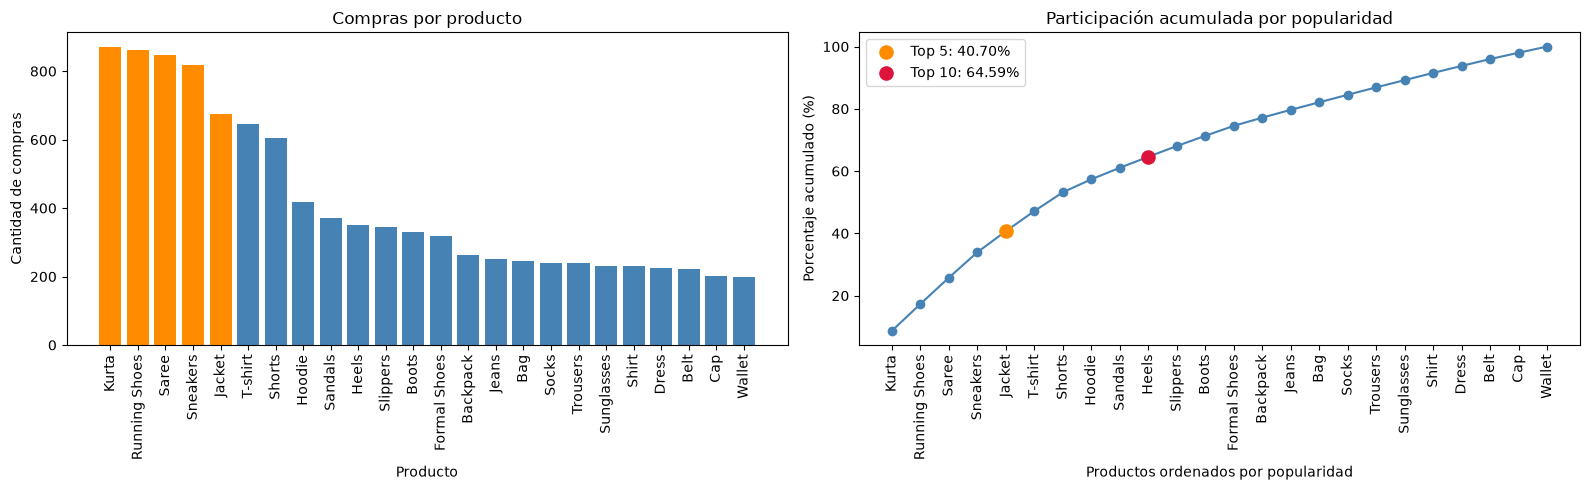

In [5]:
product_popularity = (
    df["Item Purchased"]
    .value_counts()
)
popularity_df = (
    product_popularity
    .rename("Compras")
    .reset_index()
    .rename(columns={"Item Purchased": "Producto"})
)
popularity_df["Porcentaje"] = (
    popularity_df["Compras"]
    / popularity_df["Compras"].sum()
    * 100
)
popularity_df["Porcentaje acumulado"] = (
    popularity_df["Porcentaje"]
    .cumsum()
)
# Indicadores principales
top_5_share = (
    product_popularity.head(5).sum()
    / product_popularity.sum()
    * 100
)
top_10_share = (
    product_popularity.head(10).sum()
    / product_popularity.sum()
    * 100
)
bottom_12_share = (
    product_popularity.tail(12).sum()
    / product_popularity.sum()
    * 100
)
popularity_ratio = (
    product_popularity.max()
    / product_popularity.min()
)
popularity_metrics = pd.DataFrame({
    "Indicador": [
        "Top 5 productos",
        "Top 10 productos",
        "Mitad menos vendida (12 productos)",
        "Relación más vendido / menos vendido",
    ],
    "Resultado": [
        f"{top_5_share:.2f}% de las compras",
        f"{top_10_share:.2f}% de las compras",
        f"{bottom_12_share:.2f}% de las compras",
        f"{popularity_ratio:.2f}x",
    ],
})
# Mostrar tabla de indicadores
display(
    HTML(
        f"""
        <div style="width:520px;">
            <h4>Indicadores de popularidad</h4>
            {popularity_metrics.to_html(index=False)}
        </div>
        """
    )
)
# Visualizaciones
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)
# Resaltar Top 5 frente al resto del catálogo
bar_colors = [
    "darkorange" if i < 5 else "steelblue"
    for i in range(len(popularity_df))
]
axes[0].bar(
    popularity_df["Producto"],
    popularity_df["Compras"],
    color=bar_colors,
)
axes[0].set_title("Compras por producto")
axes[0].set_xlabel("Producto")
axes[0].set_ylabel("Cantidad de compras")
axes[0].tick_params(
    axis="x",
    rotation=90
)
# Curva acumulada
axes[1].plot(
    popularity_df["Producto"],
    popularity_df["Porcentaje acumulado"],
    marker="o",
    color="steelblue",
)
# Resaltar Top 5
axes[1].scatter(
    popularity_df.loc[4, "Producto"],
    popularity_df.loc[4, "Porcentaje acumulado"],
    color="darkorange",
    s=90,
    zorder=3,
    label=f"Top 5: {top_5_share:.2f}%",
)
# Resaltar Top 10
axes[1].scatter(
    popularity_df.loc[9, "Producto"],
    popularity_df.loc[9, "Porcentaje acumulado"],
    color="crimson",
    s=90,
    zorder=3,
    label=f"Top 10: {top_10_share:.2f}%",
)
axes[1].set_title(
    "Participación acumulada por popularidad"
)
axes[1].set_xlabel(
    "Productos ordenados por popularidad"
)
axes[1].set_ylabel(
    "Porcentaje acumulado (%)"
)
axes[1].tick_params(
    axis="x",
    rotation=90
)
axes[1].legend()
plt.tight_layout()
plt.show()

La distribución de popularidad presenta una concentración moderada. Los cinco productos con mayor cantidad de compras representan el 40,70% de las transacciones y los diez primeros alcanzan el 64,59%. Sin embargo, no se observa una long tail extrema: los doce productos menos vendidos todavía concentran el 28,66% de las compras y el producto más popular registra únicamente 4,39 veces el volumen del menos popular. Esto indica que el catálogo de 24 productos posee una cabeza de popularidad definida, pero mantiene un nivel relevante de interacción en prácticamente todo el catálogo. Por lo tanto, la popularidad puede utilizarse como señal de respaldo sin asumir que los productos de menor rotación carecen de soporte histórico.

#### 6) Cobertura y soporte de las relaciones entre productos

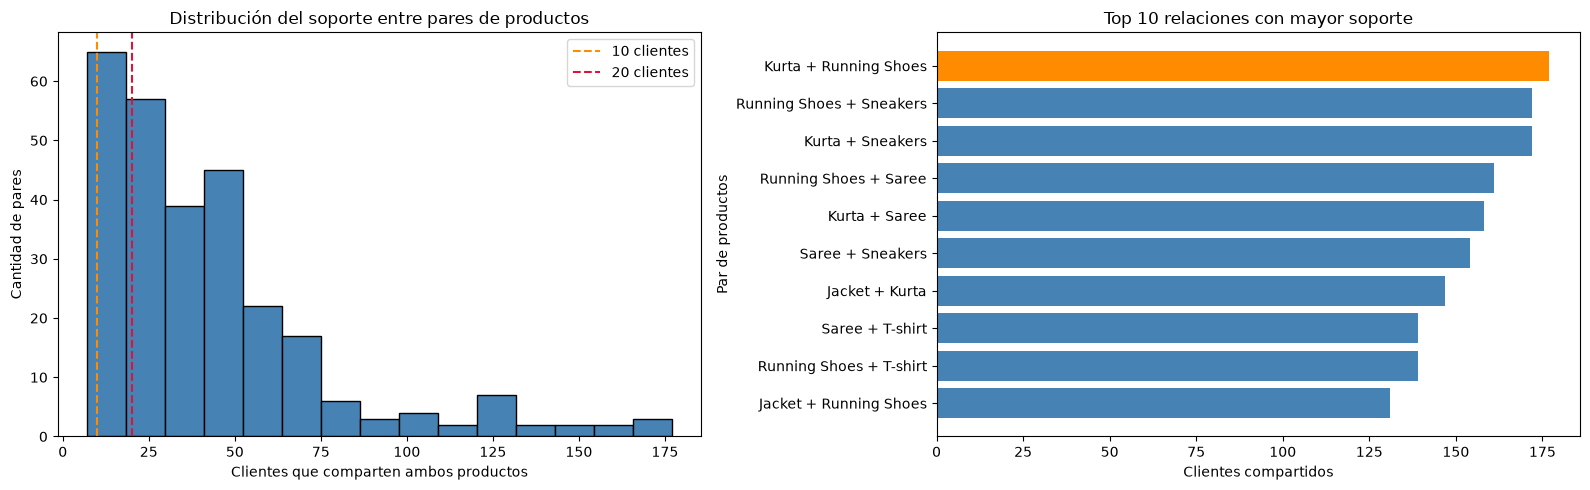

In [6]:
# Convertir la matriz cliente-producto a presencia binaria
binary_customer_item = (
    customer_item_matrix > 0
).astype(int)
# Matriz de coocurrencias entre productos
item_cooccurrence = (
    binary_customer_item.T
    .dot(binary_customer_item)
)
# Construir tabla con todos los pares posibles
pair_support = []
for item_a, item_b in combinations(
    item_cooccurrence.columns,
    2
):
    pair_support.append({
        "Producto A": item_a,
        "Producto B": item_b,
        "Clientes compartidos": int(
            item_cooccurrence.loc[item_a, item_b]
        ),
    })
pair_support_df = pd.DataFrame(pair_support)
# Indicadores de cobertura y soporte
total_pairs = len(pair_support_df)
coverage_metrics = pd.DataFrame({
    "Indicador": [
        "Pares posibles",
        "Pares sin coocurrencias",
        "Pares con >=5 clientes",
        "Pares con >=10 clientes",
        "Pares con >=20 clientes",
        "Coocurrencia mínima",
        "Coocurrencia mediana",
        "Coocurrencia media",
        "Coocurrencia máxima",
    ],
    "Resultado": [
        total_pairs,
        (
            pair_support_df["Clientes compartidos"] == 0
        ).sum(),
        (
            pair_support_df["Clientes compartidos"] >= 5
        ).sum(),
        (
            pair_support_df["Clientes compartidos"] >= 10
        ).sum(),
        (
            pair_support_df["Clientes compartidos"] >= 20
        ).sum(),
        pair_support_df["Clientes compartidos"].min(),
        pair_support_df["Clientes compartidos"].median(),
        round(
            pair_support_df["Clientes compartidos"].mean(),
            2,
        ),
        pair_support_df["Clientes compartidos"].max(),
    ],
})
# Agregar porcentajes a los indicadores de cobertura
coverage_metrics["Cobertura"] = [
    "100.00%",
    f"{((pair_support_df['Clientes compartidos'] == 0).mean() * 100):.2f}%",
    f"{((pair_support_df['Clientes compartidos'] >= 5).mean() * 100):.2f}%",
    f"{((pair_support_df['Clientes compartidos'] >= 10).mean() * 100):.2f}%",
    f"{((pair_support_df['Clientes compartidos'] >= 20).mean() * 100):.2f}%",
    "",
    "",
    "",
    "",
]
# Top 10 pares por cantidad de clientes compartidos
top_pairs = (
    pair_support_df
    .sort_values(
        "Clientes compartidos",
        ascending=False,
    )
    .head(10)
    .copy()
)
top_pairs["Par"] = (
    top_pairs["Producto A"]
    + " + "
    + top_pairs["Producto B"]
)

top_pairs_table = top_pairs[
    ["Par", "Clientes compartidos"]
]
# Mostrar las dos tablas lado a lado
display(
    HTML(
        f"""
        <div style="display:flex; gap:40px; align-items:flex-start;">
            <div>
                <h4>Indicadores de cobertura</h4>
                {coverage_metrics.to_html(index=False)}
            </div>
            <div>
                <h4>Top 10 pares con mayor soporte</h4>
                {top_pairs_table.to_html(index=False)}
            </div>
        </div>
        """
    )
)
# Visualizaciones
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)
# Distribución del soporte entre pares
axes[0].hist(
    pair_support_df["Clientes compartidos"],
    bins=15,
    color="steelblue",
    edgecolor="black",
)
axes[0].axvline(
    10,
    color="darkorange",
    linestyle="--",
    label="10 clientes",
)
axes[0].axvline(
    20,
    color="crimson",
    linestyle="--",
    label="20 clientes",
)
axes[0].set_title(
    "Distribución del soporte entre pares de productos"
)
axes[0].set_xlabel(
    "Clientes que comparten ambos productos"
)
axes[0].set_ylabel(
    "Cantidad de pares"
)
axes[0].legend()
# Top 10 pares con mayor soporte
top_pairs_plot = top_pairs.sort_values(
    "Clientes compartidos"
)
axes[1].barh(
    top_pairs_plot["Par"],
    top_pairs_plot["Clientes compartidos"],
    color="steelblue",
)
# Resaltar el par con mayor soporte
axes[1].barh(
    top_pairs_plot.iloc[-1]["Par"],
    top_pairs_plot.iloc[-1]["Clientes compartidos"],
    color="darkorange",
)
axes[1].set_title(
    "Top 10 relaciones con mayor soporte"
)
axes[1].set_xlabel(
    "Clientes compartidos"
)
axes[1].set_ylabel(
    "Par de productos"
)
plt.tight_layout()
plt.show()

La red de relaciones entre productos presenta cobertura completa: los 276 pares posibles del catálogo registran al menos una coocurrencia dentro del historial de clientes. El soporte también resulta amplio. El 96,74% de los pares aparece en el historial de al menos 10 clientes y el 74,64% alcanza 20 o más, con una mediana de 34 clientes compartidos por relación. Estos resultados indican que el catálogo dispone de suficiente conectividad histórica para explorar relaciones item-item. Sin embargo, una alta coocurrencia no implica necesariamente una afinidad específica entre productos, ya que los artículos más populares pueden compartir clientes simplemente por su mayor frecuencia de compra. Por este motivo, el soporte debe complementarse con una medida de asociación ajustada por popularidad.

#### 7) Afinidad entre productos ajustada por popularidad (Lift)

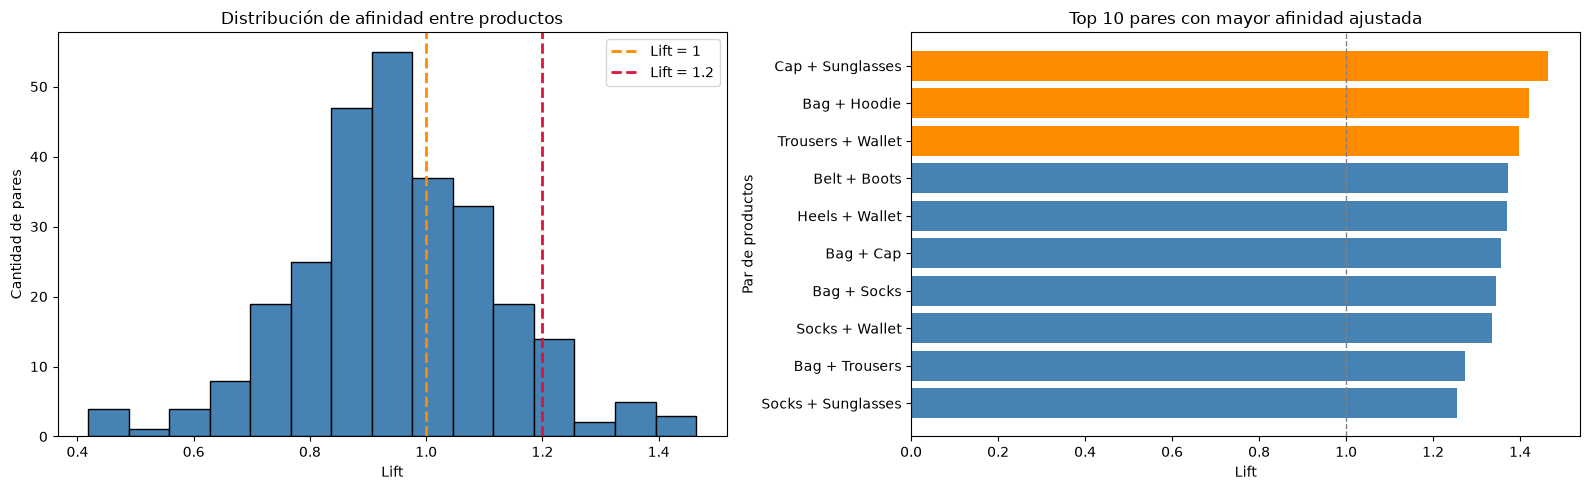

In [7]:
# Soporte individual de cada producto
item_support = binary_customer_item.sum(axis=0)
# Cantidad total de clientes
n_customers = binary_customer_item.shape[0]
# Calcular Lift para cada par
pair_support_df["Lift"] = (
    pair_support_df["Clientes compartidos"]
    * n_customers
    / (
        pair_support_df["Producto A"].map(item_support)
        * pair_support_df["Producto B"].map(item_support)
    )
)
# Resumen estadístico del Lift
lift_summary = pd.DataFrame({
    "Estadística": [
        "Mínimo",
        "Q25",
        "Mediana",
        "Q75",
        "Media",
        "Máximo",
    ],
    "Lift": [
        pair_support_df["Lift"].min(),
        pair_support_df["Lift"].quantile(0.25),
        pair_support_df["Lift"].median(),
        pair_support_df["Lift"].quantile(0.75),
        pair_support_df["Lift"].mean(),
        pair_support_df["Lift"].max(),
    ],
})
lift_summary["Lift"] = (
    lift_summary["Lift"]
    .round(3)
)
# Cantidad de pares según nivel de asociación
lift_thresholds = pd.DataFrame({
    "Criterio": [
        "Lift > 1.0",
        "Lift >= 1.2",
        "Lift >= 1.5",
    ],
    "Pares": [
        int((pair_support_df["Lift"] > 1.0).sum()),
        int((pair_support_df["Lift"] >= 1.2).sum()),
        int((pair_support_df["Lift"] >= 1.5).sum()),
    ],
})
lift_thresholds["Porcentaje"] = [
    f"{(pair_support_df['Lift'] > 1.0).mean() * 100:.2f}%",
    f"{(pair_support_df['Lift'] >= 1.2).mean() * 100:.2f}%",
    f"{(pair_support_df['Lift'] >= 1.5).mean() * 100:.2f}%",
]
# Top 10 relaciones con mayor Lift
top_lift = (
    pair_support_df
    .sort_values(
        "Lift",
        ascending=False,
    )
    .head(10)
    .copy()
)
top_lift["Par"] = (
    top_lift["Producto A"]
    + " + "
    + top_lift["Producto B"]
)
top_lift_table = top_lift[
    [
        "Par",
        "Clientes compartidos",
        "Lift",
    ]
].copy()
top_lift_table["Lift"] = (
    top_lift_table["Lift"]
    .round(3)
)
# Mostrar las tres tablas lado a lado
display(
    HTML(
        f"""
        <div style="display:flex; gap:35px; align-items:flex-start;">
            <div>
                <h4>Distribución del Lift</h4>
                {lift_summary.to_html(index=False)}
            </div>

            <div>
                <h4>Relaciones con asociación positiva</h4>
                {lift_thresholds.to_html(index=False)}
            </div>

            <div>
                <h4>Top 10 pares con mayor Lift</h4>
                {top_lift_table.to_html(index=False)}
            </div>
        </div>
        """
    )
)
# Visualizaciones
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)
# Distribución general del Lift
axes[0].hist(
    pair_support_df["Lift"],
    bins=15,
    color="steelblue",
    edgecolor="black",
)
axes[0].axvline(
    1.0,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="Lift = 1",
)
axes[0].axvline(
    1.2,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Lift = 1.2",
)
axes[0].set_title(
    "Distribución de afinidad entre productos"
)
axes[0].set_xlabel("Lift")
axes[0].set_ylabel("Cantidad de pares")
axes[0].legend()
# Colores según fuerza de asociación
top_lift_colors = [
    "crimson"
    if value >= 1.5
    else "darkorange"
    if value >= 1.2
    else "steelblue"
    for value in top_lift["Lift"]
]
top_lift_plot = (
    top_lift
    .sort_values("Lift")
    .copy()
)
top_lift_plot_colors = [
    "darkorange"
    if i >= len(top_lift_plot) - 3
    else "steelblue"
    for i in range(len(top_lift_plot))
]
axes[1].barh(
    top_lift_plot["Par"],
    top_lift_plot["Lift"],
    color=top_lift_plot_colors,
)
axes[1].axvline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1,
)
axes[1].set_title(
    "Top 10 pares con mayor afinidad ajustada"
)
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("Par de productos")
plt.tight_layout()
plt.show()

El análisis de Lift muestra que la amplia coocurrencia observada entre productos no implica una afinidad fuerte de manera generalizada. La mediana del Lift es 0,941 y la media 0,949, valores cercanos a 1. Solo el 36,59% de los 276 pares presenta una asociación positiva superior a la esperada por popularidad, mientras que apenas el 7,97% alcanza un Lift igual o superior a 1,2. Ningún par supera 1,5. Esto indica que existe señal de afinidad entre determinados productos, pero dicha señal se concentra en un subconjunto reducido del catálogo. En consecuencia, la matriz item-item dispone de cobertura suficiente para operar, aunque no todas las relaciones presentan el mismo poder discriminante y la popularidad individual de los productos explica una parte importante de las coocurrencias observadas. Por este motivo, las relaciones item-item deben interpretarse como una fuente de señal complementaria y no como evidencia de afinidad fuerte entre todos los productos del catálogo.

#### 8) Cold start y disponibilidad de historial en un escenario temporal

Indicador,Resultado,Porcentaje
Fecha de corte,2024-08-06,
Transacciones históricas,7996,
Transacciones futuras,2004,
Clientes en período futuro,1510,100.00%
Clientes ya conocidos,1345,89.07%
Clientes nuevos (cold start),165,10.93%
Historial previo,Clientes,Porcentaje
1 producto,365,27.14%
>=2 productos,980,72.86%
>=3 productos,555,41.26%


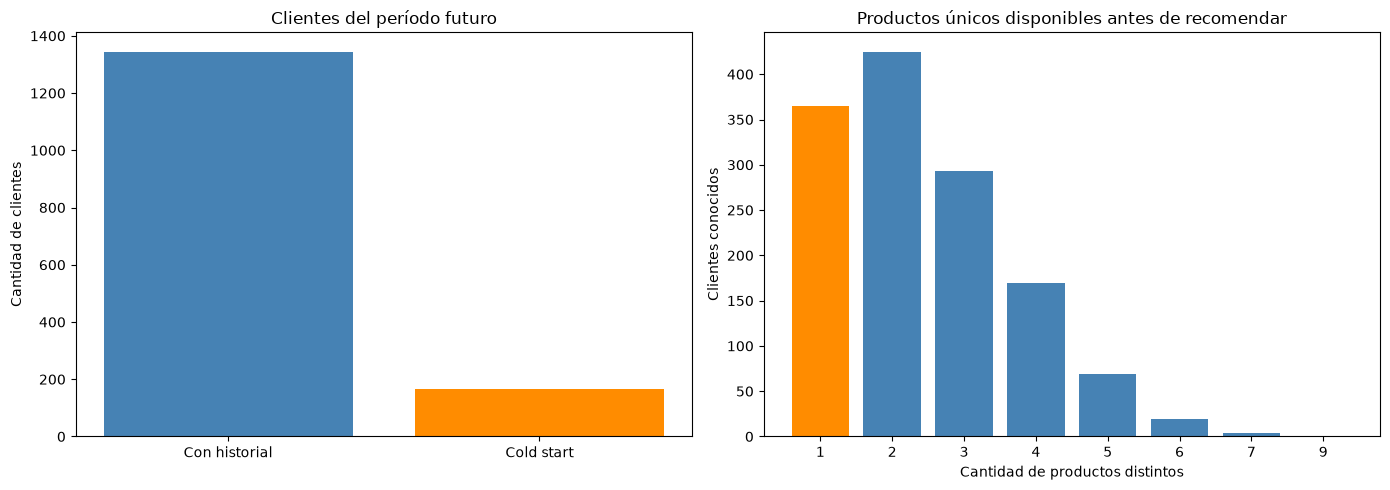

In [8]:
# Orden temporal y corte 80/20
df_temporal = df.copy()
df_temporal["Purchase Date"] = pd.to_datetime(
    df_temporal["Purchase Date"]
)
cutoff_date = df_temporal[
    "Purchase Date"
].quantile(0.80)
train_data = df_temporal[
    df_temporal["Purchase Date"] < cutoff_date
]
test_data = df_temporal[
    df_temporal["Purchase Date"] >= cutoff_date
]
# Clientes conocidos y clientes nuevos
train_customers = set(
    train_data["Customer ID"]
)
test_customers = set(
    test_data["Customer ID"]
)
known_customers = (
    train_customers
    & test_customers
)
new_customers = (
    test_customers
    - train_customers
)
new_customer_transactions = test_data[
    test_data["Customer ID"].isin(
        new_customers
    )
]
# Historial previo de clientes conocidos
known_history = (
    train_data[
        train_data["Customer ID"].isin(
            known_customers
        )
    ]
    .groupby("Customer ID")["Item Purchased"]
    .nunique()
)
# Tabla 1: escenario temporal
cold_start_metrics = pd.DataFrame({
    "Indicador": [
        "Fecha de corte",
        "Transacciones históricas",
        "Transacciones futuras",
        "Clientes en período futuro",
        "Clientes ya conocidos",
        "Clientes nuevos (cold start)",
    ],
    "Resultado": [
        cutoff_date.date(),
        len(train_data),
        len(test_data),
        len(test_customers),
        len(known_customers),
        len(new_customers),
    ],
    "Porcentaje": [
        "",
        "",
        "",
        "100.00%",
        f"{len(known_customers) / len(test_customers) * 100:.2f}%",
        f"{len(new_customers) / len(test_customers) * 100:.2f}%",
    ],
})
# Tabla 2: profundidad del historial disponible
known_history_metrics = pd.DataFrame({
    "Historial previo": [
        "1 producto",
        ">=2 productos",
        ">=3 productos",
        ">=5 productos",
    ],
    "Clientes": [
        int((known_history == 1).sum()),
        int((known_history >= 2).sum()),
        int((known_history >= 3).sum()),
        int((known_history >= 5).sum()),
    ],
    "Porcentaje": [
        f"{(known_history == 1).mean() * 100:.2f}%",
        f"{(known_history >= 2).mean() * 100:.2f}%",
        f"{(known_history >= 3).mean() * 100:.2f}%",
        f"{(known_history >= 5).mean() * 100:.2f}%",
    ],
})
# Mostrar tablas lado a lado
display(
    HTML(
        f"""
        <div style="display:flex; gap:40px; align-items:flex-start;">
            <div>
                <h4>Escenario temporal 80/20</h4>
                {cold_start_metrics.to_html(index=False)}
            </div>

            <div>
                <h4>Historial previo de clientes conocidos</h4>
                {known_history_metrics.to_html(index=False)}
            </div>
        </div>
        """
    )
)
# Visualizaciones
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)
# Clientes conocidos vs nuevos
customer_groups = [
    len(known_customers),
    len(new_customers),
]
axes[0].bar(
    ["Con historial", "Cold start"],
    customer_groups,
    color=["steelblue", "darkorange"],
)
axes[0].set_title(
    "Clientes del período futuro"
)
axes[0].set_ylabel(
    "Cantidad de clientes"
)
# Historial previo disponible
history_distribution = (
    known_history
    .value_counts()
    .sort_index()
)
history_colors = [
    "darkorange"
    if products == 1
    else "steelblue"
    for products in history_distribution.index
]
axes[1].bar(
    history_distribution.index.astype(str),
    history_distribution.values,
    color=history_colors,
)
axes[1].set_title(
    "Productos únicos disponibles antes de recomendar"
)
axes[1].set_xlabel(
    "Cantidad de productos distintos"
)
axes[1].set_ylabel(
    "Clientes conocidos"
)
plt.tight_layout()
plt.show()

El corte temporal 80/20 muestra que el cold start representa una situación relevante pero acotada: el 10,93% de los clientes observados en el período futuro no tenía historial previo, mientras que el 89,07% ya había realizado al menos una compra anteriormente. Sin embargo, disponer de historial no implica necesariamente contar con un perfil suficientemente profundo. Entre los clientes conocidos, el 27,14% tenía únicamente un producto distinto registrado antes del período de evaluación y solo el 41,26% contaba con tres o más productos distintos. Esto indica que la principal limitación no proviene únicamente de los clientes completamente nuevos, sino también de los clientes conocidos con historiales todavía escasos. En consecuencia, la disponibilidad de mecanismos de fallback resulta necesaria tanto para situaciones de cold start como para perfiles con evidencia insuficiente.

#### 9) Historial disponible en clientes inactivos de 270 días

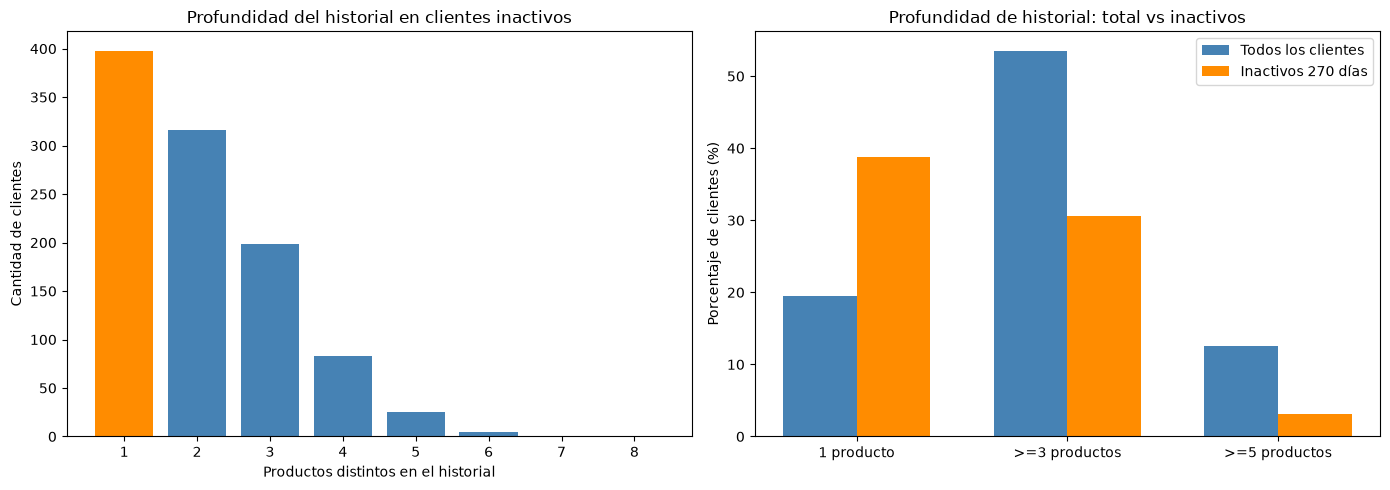

In [9]:
# Fecha de referencia y umbral de inactividad
reference_date = pd.to_datetime(
    df["Purchase Date"]
).max()
inactivity_cutoff = (
    reference_date
    - pd.Timedelta(days=270)
)
# Última compra por cliente
last_purchase = (
    df.assign(
        **{
            "Purchase Date": pd.to_datetime(
                df["Purchase Date"]
            )
        }
    )
    .groupby("Customer ID")["Purchase Date"]
    .max()
)
# Clientes con 270 días o más sin comprar
inactive_customers = (
    last_purchase[
        last_purchase <= inactivity_cutoff
    ]
    .index
)
inactive_data = df[
    df["Customer ID"].isin(
        inactive_customers
    )
]
# Cantidad de productos distintos en su historial
inactive_history = (
    inactive_data
    .groupby("Customer ID")["Item Purchased"]
    .nunique()
)
# Tabla 1: universo de clientes inactivos
inactive_metrics = pd.DataFrame({
    "Indicador": [
        "Fecha de referencia",
        "Fecha límite 270 días",
        "Clientes totales",
        "Clientes inactivos",
        "Participación de inactivos",
        "Productos únicos promedio",
        "Mediana de productos únicos",
    ],
    "Resultado": [
        reference_date.date(),
        inactivity_cutoff.date(),
        df["Customer ID"].nunique(),
        len(inactive_customers),
        (
            f"{len(inactive_customers) / df['Customer ID'].nunique() * 100:.2f}%"
        ),
        f"{inactive_history.mean():.2f}",
        f"{inactive_history.median():.2f}",
    ],
})
# Tabla 2: profundidad del historial
inactive_history_metrics = pd.DataFrame({
    "Historial": [
        "1 producto",
        ">=2 productos",
        ">=3 productos",
        ">=5 productos",
    ],
    "Clientes": [
        int((inactive_history == 1).sum()),
        int((inactive_history >= 2).sum()),
        int((inactive_history >= 3).sum()),
        int((inactive_history >= 5).sum()),
    ],
    "Porcentaje": [
        f"{(inactive_history == 1).mean() * 100:.2f}%",
        f"{(inactive_history >= 2).mean() * 100:.2f}%",
        f"{(inactive_history >= 3).mean() * 100:.2f}%",
        f"{(inactive_history >= 5).mean() * 100:.2f}%",
    ],
})
# Comparación con el universo completo
history_comparison = pd.DataFrame({
    "Indicador": [
        "1 producto",
        ">=2 productos",
        ">=3 productos",
        ">=5 productos",
    ],
    "Todos los clientes": [
        f"{(customer_history == 1).mean() * 100:.2f}%",
        f"{(customer_history >= 2).mean() * 100:.2f}%",
        f"{(customer_history >= 3).mean() * 100:.2f}%",
        f"{(customer_history >= 5).mean() * 100:.2f}%",
    ],
    "Inactivos 270 días": [
        f"{(inactive_history == 1).mean() * 100:.2f}%",
        f"{(inactive_history >= 2).mean() * 100:.2f}%",
        f"{(inactive_history >= 3).mean() * 100:.2f}%",
        f"{(inactive_history >= 5).mean() * 100:.2f}%",
    ],
})
# Mostrar las tres tablas horizontalmente
display(
    HTML(
        f"""
        <div style="display:flex; gap:35px; align-items:flex-start;">
            <div>
                <h4>Clientes objetivo de reactivación</h4>
                {inactive_metrics.to_html(index=False)}
            </div>

            <div>
                <h4>Historial de clientes inactivos</h4>
                {inactive_history_metrics.to_html(index=False)}
            </div>

            <div>
                <h4>Comparación con el universo total</h4>
                {history_comparison.to_html(index=False)}
            </div>
        </div>
        """
    )
)
# Visualizaciones
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)
# Distribución del historial de clientes inactivos
inactive_distribution = (
    inactive_history
    .value_counts()
    .sort_index()
)
inactive_colors = [
    "darkorange"
    if products == 1
    else "steelblue"
    for products in inactive_distribution.index
]
axes[0].bar(
    inactive_distribution.index.astype(str),
    inactive_distribution.values,
    color=inactive_colors,
)
axes[0].set_title(
    "Profundidad del historial en clientes inactivos"
)
axes[0].set_xlabel(
    "Productos distintos en el historial"
)
axes[0].set_ylabel(
    "Cantidad de clientes"
)
# Comparación: todos vs inactivos
comparison_labels = [
    "1 producto",
    ">=3 productos",
    ">=5 productos",
]
all_customer_values = [
    (customer_history == 1).mean() * 100,
    (customer_history >= 3).mean() * 100,
    (customer_history >= 5).mean() * 100,
]
inactive_values = [
    (inactive_history == 1).mean() * 100,
    (inactive_history >= 3).mean() * 100,
    (inactive_history >= 5).mean() * 100,
]
x = np.arange(
    len(comparison_labels)
)
width = 0.35
axes[1].bar(
    x - width / 2,
    all_customer_values,
    width,
    label="Todos los clientes",
    color="steelblue",
)
axes[1].bar(
    x + width / 2,
    inactive_values,
    width,
    label="Inactivos 270 días",
    color="darkorange",
)
axes[1].set_title(
    "Profundidad de historial: total vs inactivos"
)
axes[1].set_ylabel(
    "Porcentaje de clientes (%)"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    comparison_labels
)
axes[1].legend()
plt.tight_layout()
plt.show()

Los clientes objetivo del modo Reactivación presentan historiales sensiblemente más limitados que el universo general. Con la fecha máxima del dataset como referencia, 1.028 clientes —el 31,24% del total— cumplen el criterio de 270 días o más sin comprar. Dentro de este grupo, el historial promedio es de apenas 2,07 productos distintos por cliente y la mediana es de 2. El 38,72% de los clientes inactivos registra un único producto en su historial, prácticamente el doble del 19,45% observado en el conjunto total. La diferencia también aparece en los historiales más profundos: mientras el 53,54% del total de clientes posee tres o más productos distintos, entre los inactivos esta proporción cae al 30,54%. Para cinco o más productos, la cobertur a disminuye del 12,52% al 3,11%. Esto evidencia que el segmento que ReActiva busca recuperar es precisamente uno de los grupos con menor información histórica disponible. Por lo tanto, los mecanismos de recomendación personalizada cuentan con menor evidencia individual en este escenario y la existencia de estrategias de fallback resulta especialmente relevante para mantener cobertura en el modo Reactivación.

#### 10) Estabilidad temporal de la popularidad y las relaciones entre productos

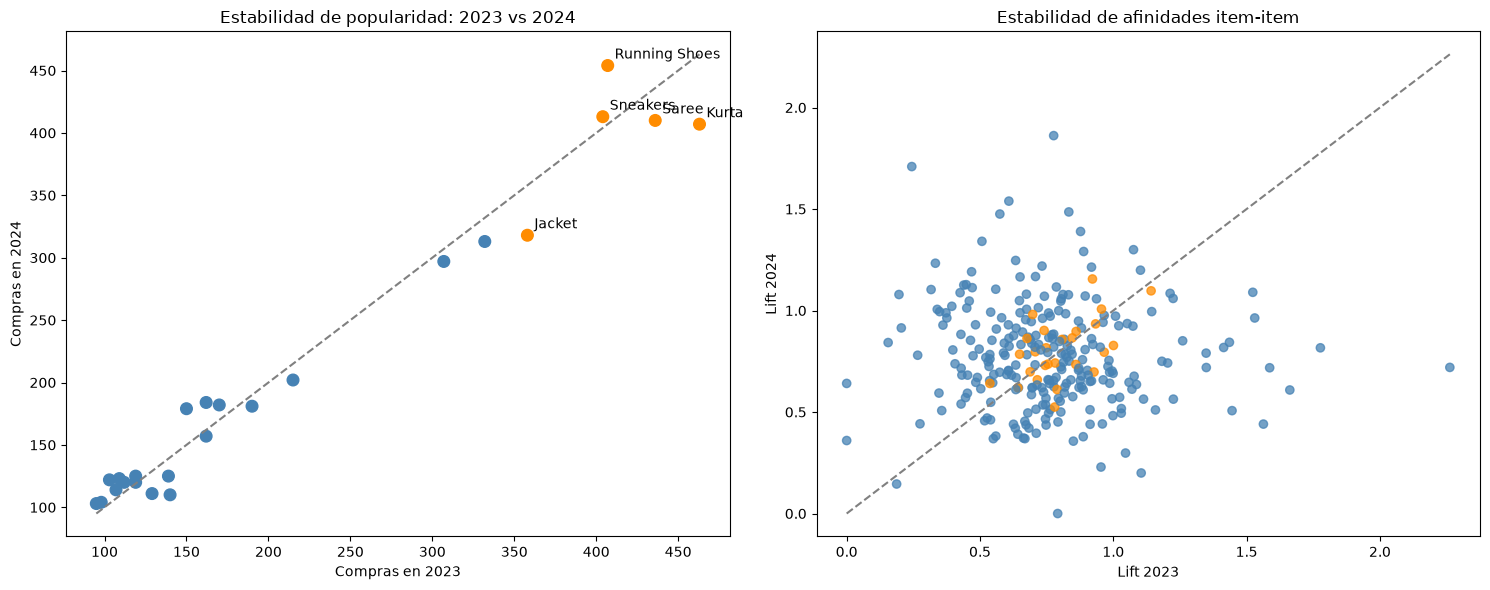

In [10]:
# Preparar información temporal
temporal_stability_df = df.copy()
temporal_stability_df["Purchase Date"] = pd.to_datetime(
    temporal_stability_df["Purchase Date"]
)
temporal_stability_df["Año"] = (
    temporal_stability_df["Purchase Date"].dt.year
)
# ============================================================
# 1. ESTABILIDAD DE POPULARIDAD
# ============================================================
yearly_popularity = pd.crosstab(
    temporal_stability_df["Item Purchased"],
    temporal_stability_df["Año"],
)
popularity_spearman = (
    yearly_popularity[2023]
    .corr(
        yearly_popularity[2024],
        method="spearman",
    )
)
top_2023 = (
    yearly_popularity[2023]
    .sort_values(ascending=False)
    .head(5)
)
top_2024 = (
    yearly_popularity[2024]
    .sort_values(ascending=False)
    .head(5)
)
top_products_table = pd.DataFrame({
    "Ranking": range(1, 6),
    "Top 2023": top_2023.index,
    "Compras 2023": top_2023.values,
    "Top 2024": top_2024.index,
    "Compras 2024": top_2024.values,
})
# ============================================================
# 2. ESTABILIDAD DE LIFT ITEM-ITEM
# ============================================================
all_items = sorted(
    temporal_stability_df["Item Purchased"].unique()
)
def calculate_lift_by_year(data):
    matrix = (
        pd.crosstab(
            data["Customer ID"],
            data["Item Purchased"],
        )
        .reindex(
            columns=all_items,
            fill_value=0,
        )
        .gt(0)
        .astype(int)
    )
    n_customers_year = len(matrix)
    support = matrix.sum(axis=0)
    cooccurrence = matrix.T.dot(matrix)
    rows = []
    for item_a, item_b in combinations(
        all_items,
        2,
    ):
        shared_customers = int(
            cooccurrence.loc[item_a, item_b]
        )
        lift = (
            shared_customers
            * n_customers_year
            / (
                support[item_a]
                * support[item_b]
            )
        )
        rows.append({
            "Par": f"{item_a} + {item_b}",
            "Coocurrencia": shared_customers,
            "Lift": lift,
        })
    return pd.DataFrame(rows).set_index("Par")
lift_2023 = calculate_lift_by_year(
    temporal_stability_df[
        temporal_stability_df["Año"] == 2023
    ]
)
lift_2024 = calculate_lift_by_year(
    temporal_stability_df[
        temporal_stability_df["Año"] == 2024
    ]
)
lift_comparison = (
    lift_2023
    .join(
        lift_2024,
        lsuffix="_2023",
        rsuffix="_2024",
    )
)
lift_spearman = (
    lift_comparison["Lift_2023"]
    .corr(
        lift_comparison["Lift_2024"],
        method="spearman",
    )
)
top_lift_2023 = set(
    lift_comparison["Lift_2023"]
    .nlargest(10)
    .index
)
top_lift_2024 = set(
    lift_comparison["Lift_2024"]
    .nlargest(10)
    .index
)
top_10_overlap = len(
    top_lift_2023 & top_lift_2024
)
# ============================================================
# 3. ESTABILIDAD SEGÚN SOPORTE
# ============================================================
support_rows = []
for threshold in [5, 10, 15, 20, 25]:
    filtered = lift_comparison[
        (
            lift_comparison["Coocurrencia_2023"]
            >= threshold
        )
        & (
            lift_comparison["Coocurrencia_2024"]
            >= threshold
        )
    ]
    correlation = (
        filtered["Lift_2023"]
        .corr(
            filtered["Lift_2024"],
            method="spearman",
        )
        if len(filtered) > 1
        else np.nan
    )
    support_rows.append({
        "Soporte mínimo": f">= {threshold}",
        "Pares comparables": len(filtered),
        "Spearman Lift": round(correlation, 3),
    })
support_stability = pd.DataFrame(
    support_rows
)
# ============================================================
# 4. RESUMEN
# ============================================================
temporal_summary = pd.DataFrame({
    "Indicador": [
        "Transacciones 2023",
        "Transacciones 2024",
        "Spearman popularidad",
        "Spearman Lift",
        "Coincidencias Top 10 Lift",
    ],
    "Resultado": [
        int(
            (
                temporal_stability_df["Año"]
                == 2023
            ).sum()
        ),
        int(
            (
                temporal_stability_df["Año"]
                == 2024
            ).sum()
        ),
        f"{popularity_spearman:.3f}",
        f"{lift_spearman:.3f}",
        f"{top_10_overlap} de 10",
    ],
})
# Mostrar las tres tablas horizontalmente
display(
    HTML(
        f"""
        <div style="display:flex; gap:35px; align-items:flex-start;">
            <div>
                <h4>Resumen temporal</h4>
                {temporal_summary.to_html(index=False)}
            </div>

            <div>
                <h4>Top 5 productos por año</h4>
                {top_products_table.to_html(index=False)}
            </div>

            <div>
                <h4>Estabilidad del Lift según soporte</h4>
                {support_stability.to_html(index=False)}
            </div>
        </div>
        """
    )
)
# ============================================================
# 5. VISUALIZACIONES
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)
# ------------------------------------------------------------
# Popularidad 2023 vs 2024
# ------------------------------------------------------------
stable_top_5 = (
    set(top_2023.index)
    & set(top_2024.index)
)
popularity_colors = [
    "darkorange"
    if product in stable_top_5
    else "steelblue"
    for product in yearly_popularity.index
]
axes[0].scatter(
    yearly_popularity[2023],
    yearly_popularity[2024],
    color=popularity_colors,
    s=70,
)
pop_min = min(
    yearly_popularity[2023].min(),
    yearly_popularity[2024].min(),
)
pop_max = max(
    yearly_popularity[2023].max(),
    yearly_popularity[2024].max(),
)
axes[0].plot(
    [pop_min, pop_max],
    [pop_min, pop_max],
    linestyle="--",
    color="gray",
)
for product in stable_top_5:
    axes[0].annotate(
        product,
        (
            yearly_popularity.loc[
                product,
                2023,
            ],
            yearly_popularity.loc[
                product,
                2024,
            ],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )
axes[0].set_title(
    "Estabilidad de popularidad: 2023 vs 2024"
)
axes[0].set_xlabel(
    "Compras en 2023"
)
axes[0].set_ylabel(
    "Compras en 2024"
)
# ------------------------------------------------------------
# Lift 2023 vs 2024
# ------------------------------------------------------------
high_support_mask = (
    (
        lift_comparison[
            "Coocurrencia_2023"
        ] >= 20
    )
    & (
        lift_comparison[
            "Coocurrencia_2024"
        ] >= 20
    )
)
lift_colors = [
    "darkorange"
    if high_support
    else "steelblue"
    for high_support
    in high_support_mask
]
axes[1].scatter(
    lift_comparison["Lift_2023"],
    lift_comparison["Lift_2024"],
    color=lift_colors,
    alpha=0.75,
)
lift_min = min(
    lift_comparison["Lift_2023"].min(),
    lift_comparison["Lift_2024"].min(),
)
lift_max = max(
    lift_comparison["Lift_2023"].max(),
    lift_comparison["Lift_2024"].max(),
)
axes[1].plot(
    [lift_min, lift_max],
    [lift_min, lift_max],
    linestyle="--",
    color="gray",
)
axes[1].set_title(
    "Estabilidad de afinidades item-item"
)
axes[1].set_xlabel(
    "Lift 2023"
)
axes[1].set_ylabel(
    "Lift 2024"
)
plt.tight_layout()
plt.show()

La comparación temporal muestra comportamientos muy diferentes entre la popularidad general de los productos y las relaciones específicas item-item. La popularidad presenta una estabilidad elevada entre 2023 y 2024, con una correlación de Spearman de 0,925. Además, los mismos cinco productos permanecen dentro del Top 5 en ambos años, aunque cambie su posición relativa. Esto indica que la señal de popularidad resulta consistente a lo largo del período analizado. En cambio, las afinidades item-item medidas mediante Lift muestran una estabilidad considerablemente menor. La correlación global entre los Lift de 2023 y 2024 es de -0,064 y ninguno de los diez pares con mayor Lift de 2023 vuelve a integrar el Top 10 de 2024. Al exigir mayor soporte histórico, la estabilidad mejora parcialmente: para relaciones presentes en al menos 20 clientes en ambos años, la correlación alcanza 0,426. Sin embargo, esta estabilidad continúa siendo moderada y disminuye nuevamente al restringir aún más la muestra, debido a la menor cantidad de pares disponibles. En consecuencia, la popularidad constituye una señal temporalmente robusta dentro del dataset actual, mientras que las afinidades específicas entre productos son más sensibles al período y al volumen de observaciones disponible. Esto respalda la utilidad de la popularidad como mecanismo de respaldo y evidencia la importancia de reevaluar periódicamente las relaciones aprendidas a medida que se incorporan nuevas transacciones.

#### 11) Evolución de la información al acumular nuevas transacciones

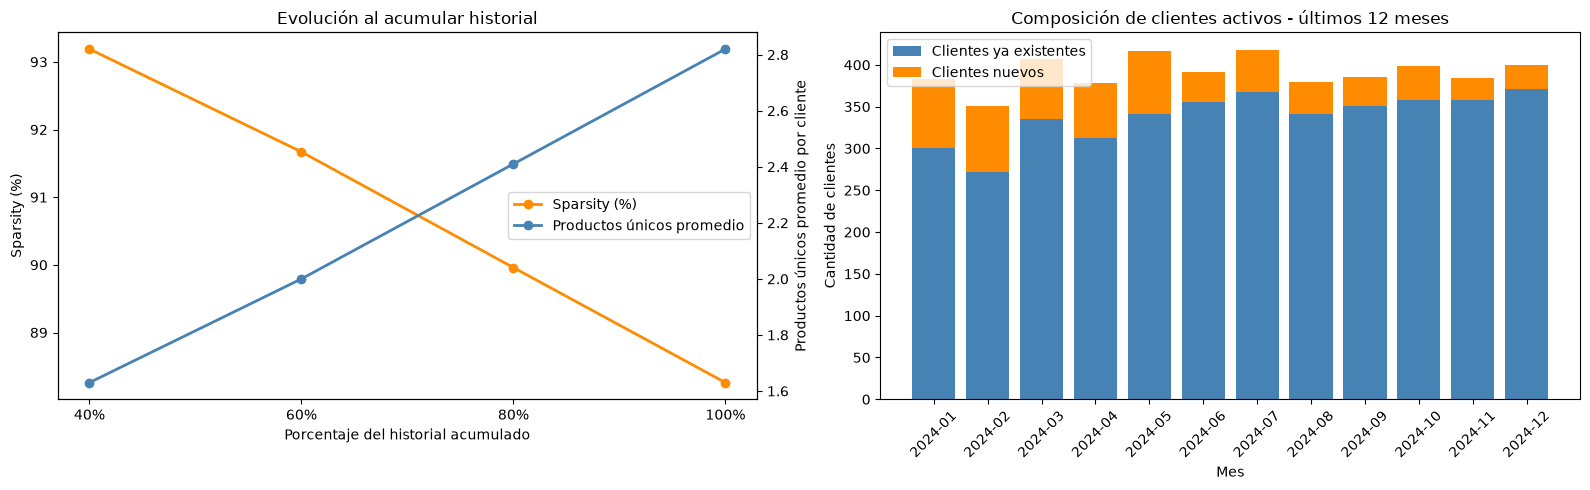

In [11]:
# Preparar dataset en orden cronológico
growth_df = df.copy()
growth_df["Purchase Date"] = pd.to_datetime(
    growth_df["Purchase Date"]
)
growth_df = growth_df.sort_values(
    "Purchase Date"
).reset_index(drop=True)
# ============================================================
# 1. EVOLUCIÓN DE LA MATRIZ AL ACUMULAR HISTORIAL
# ============================================================
history_points = [0.40, 0.60, 0.80, 1.00]
evolution_rows = []
for proportion in history_points:
    n_rows = int(
        len(growth_df) * proportion
    )
    partial_df = growth_df.iloc[:n_rows]
    partial_matrix = pd.crosstab(
        partial_df["Customer ID"],
        partial_df["Item Purchased"],
    )
    observed = (
        partial_matrix.values > 0
    ).sum()
    partial_sparsity = (
        1
        - observed / partial_matrix.size
    )
    avg_unique_products = (
        (partial_matrix > 0)
        .sum(axis=1)
        .mean()
    )
    evolution_rows.append({
        "Historial acumulado": f"{int(proportion * 100)}%",
        "Transacciones": len(partial_df),
        "Clientes": partial_matrix.shape[0],
        "Sparsity": f"{partial_sparsity * 100:.2f}%",
        "Productos únicos promedio": round(
            avg_unique_products,
            2,
        ),
    })
evolution_table = pd.DataFrame(
    evolution_rows
)
# ============================================================
# 2. FLUJO MENSUAL DE INFORMACIÓN
# ============================================================
growth_df["Mes"] = (
    growth_df["Purchase Date"]
    .dt.to_period("M")
    .astype(str)
)
first_purchase_month = (
    growth_df
    .groupby("Customer ID")["Purchase Date"]
    .min()
    .dt.to_period("M")
    .astype(str)
)
monthly_activity = (
    growth_df
    .groupby("Mes")
    .agg(
        Transacciones=(
            "Customer ID",
            "size",
        ),
        Clientes_activos=(
            "Customer ID",
            "nunique",
        ),
    )
)
monthly_activity["Clientes_nuevos"] = (
    first_purchase_month
    .value_counts()
    .reindex(
        monthly_activity.index,
        fill_value=0,
    )
)
monthly_activity["Clientes_ya_existentes"] = (
    monthly_activity["Clientes_activos"]
    - monthly_activity["Clientes_nuevos"]
)
# Resumen mensual
monthly_summary = pd.DataFrame({
    "Indicador": [
        "Meses analizados",
        "Transacciones promedio / mes",
        "Mínimo de transacciones / mes",
        "Máximo de transacciones / mes",
        "Clientes activos promedio / mes",
    ],
    "Resultado": [
        len(monthly_activity),
        round(
            monthly_activity["Transacciones"].mean(),
            2,
        ),
        int(
            monthly_activity["Transacciones"].min()
        ),
        int(
            monthly_activity["Transacciones"].max()
        ),
        round(
            monthly_activity["Clientes_activos"].mean(),
            2,
        ),
    ],
})
# Últimos 6 meses para mostrar la composición reciente
recent_months = (
    monthly_activity
    .tail(6)
    .reset_index()
)
# ============================================================
# 3. TABLAS
# ============================================================
display(
    HTML(
        f"""
        <div style="display:flex; gap:35px; align-items:flex-start;">
            <div>
                <h4>Evolución del historial acumulado</h4>
                {evolution_table.to_html(index=False)}
            </div>

            <div>
                <h4>Resumen del flujo mensual</h4>
                {monthly_summary.to_html(index=False)}
            </div>

            <div>
                <h4>Últimos 6 meses observados</h4>
                {recent_months.to_html(index=False)}
            </div>
        </div>
        """
    )
)
# ============================================================
# 4. VISUALIZACIONES
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)
# ------------------------------------------------------------
# Evolución de sparsity y profundidad del historial
# ------------------------------------------------------------
history_labels = [
    "40%",
    "60%",
    "80%",
    "100%",
]
sparsity_values = [
    93.19,
    91.67,
    89.96,
    88.26,
]
avg_products_values = [
    1.63,
    2.00,
    2.41,
    2.82,
]
axes[0].plot(
    history_labels,
    sparsity_values,
    marker="o",
    color="darkorange",
    linewidth=2,
    label="Sparsity (%)",
)
axes[0].set_title(
    "Evolución al acumular historial"
)
axes[0].set_xlabel(
    "Porcentaje del historial acumulado"
)
axes[0].set_ylabel(
    "Sparsity (%)"
)
second_axis = axes[0].twinx()
second_axis.plot(
    history_labels,
    avg_products_values,
    marker="o",
    color="steelblue",
    linewidth=2,
    label="Productos únicos promedio",
)
second_axis.set_ylabel(
    "Productos únicos promedio por cliente"
)
# Leyenda combinada
lines_1, labels_1 = (
    axes[0].get_legend_handles_labels()
)
lines_2, labels_2 = (
    second_axis.get_legend_handles_labels()
)
axes[0].legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="center right",
)
# ------------------------------------------------------------
# Composición mensual de clientes activos
# ------------------------------------------------------------
monthly_plot = (
    monthly_activity
    .tail(12)
)
axes[1].bar(
    monthly_plot.index,
    monthly_plot["Clientes_ya_existentes"],
    color="steelblue",
    label="Clientes ya existentes",
)
axes[1].bar(
    monthly_plot.index,
    monthly_plot["Clientes_nuevos"],
    bottom=monthly_plot[
        "Clientes_ya_existentes"
    ],
    color="darkorange",
    label="Clientes nuevos",
)
axes[1].set_title(
    "Composición de clientes activos - últimos 12 meses"
)
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Cantidad de clientes")
axes[1].tick_params(
    axis="x",
    rotation=45,
)
axes[1].legend()
plt.tight_layout()
plt.show()

La evolución cronológica del dataset muestra que la acumulación de nuevas transacciones incrementa progresivamente la información disponible para personalización. Al utilizar el 40% inicial del historial, la matriz cliente-producto presenta una sparsity de 93,19% y cada cliente registra en promedio 1,63 productos distintos. Con el historial completo, la sparsity disminuye a 88,26% y el promedio aumenta a 2,82 productos distintos por cliente. El crecimiento ocurre además mientras se incorporan clientes nuevos. Durante los 24 meses analizados se registran en promedio 416,67 transacciones y 392,42 clientes activos por mes. Hacia los últimos meses del período, la mayor parte de los clientes activos ya cuenta con historial previo, aunque continúa existiendo un flujo de clientes nuevos. Esto evidencia que la matriz disponible para ReActiva puede enriquecerse progresivamente a medida que se incorporan nuevas compras. Sin embargo, una mayor cantidad de datos no implica por sí sola una mejora automática de la precisión de los modelos, por lo que el desempeño deberá seguir siendo validado durante los reentrenamientos posteriores.

#### 12) Soporte del fallback de popularidad por ubicación y temporada

Indicador,Resultado
Segmentos Location + season,80.0
Transacciones promedio,125.0
Transacciones mediana,124.5
Transacciones mínimas,67.0
Transacciones máximas,208.0
Indicador,Resultado
Productos únicos promedio,23.02
Productos únicos mediana,23.50
Mínimo de productos presentes,18.00
Segmentos con los 24 productos,40.00


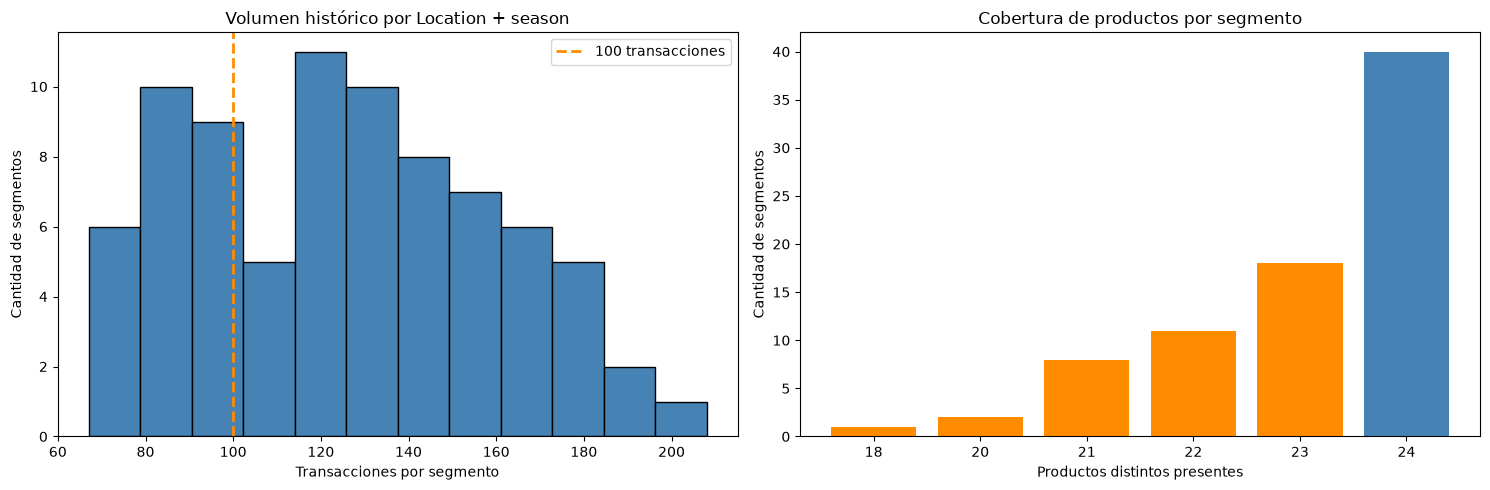

In [12]:
# Preparar temporada usando la feature estandarizada
fallback_df = add_season(df)

# ============================================================
# 1. VOLUMEN POR LOCATION + SEASON
# ============================================================
location_season_support = (
    fallback_df
    .groupby(
        ["Location", "season"]
    )
    .agg(
        Transacciones=(
            "Item Purchased",
            "size",
        ),
        Productos_unicos=(
            "Item Purchased",
            "nunique",
        ),
    )
    .reset_index()
)

# ============================================================
# 2. RESÚMENES
# ============================================================
segment_summary = pd.DataFrame({
    "Indicador": [
        "Segmentos Location + season",
        "Transacciones promedio",
        "Transacciones mediana",
        "Transacciones mínimas",
        "Transacciones máximas",
    ],
    "Resultado": [
        len(location_season_support),
        round(
            location_season_support[
                "Transacciones"
            ].mean(),
            2,
        ),
        round(
            location_season_support[
                "Transacciones"
            ].median(),
            2,
        ),
        int(
            location_season_support[
                "Transacciones"
            ].min()
        ),
        int(
            location_season_support[
                "Transacciones"
            ].max()
        ),
    ],
})

catalog_coverage_summary = pd.DataFrame({
    "Indicador": [
        "Productos únicos promedio",
        "Productos únicos mediana",
        "Mínimo de productos presentes",
        "Segmentos con los 24 productos",
        "Segmentos con <100 transacciones",
        "Segmentos con <50 transacciones",
    ],
    "Resultado": [
        round(
            location_season_support[
                "Productos_unicos"
            ].mean(),
            2,
        ),
        round(
            location_season_support[
                "Productos_unicos"
            ].median(),
            2,
        ),
        int(
            location_season_support[
                "Productos_unicos"
            ].min()
        ),
        int(
            (
                location_season_support[
                    "Productos_unicos"
                ] == 24
            ).sum()
        ),
        int(
            (
                location_season_support[
                    "Transacciones"
                ] < 100
            ).sum()
        ),
        int(
            (
                location_season_support[
                    "Transacciones"
                ] < 50
            ).sum()
        ),
    ],
})

lowest_support_segments = (
    location_season_support
    .sort_values(
        "Transacciones"
    )
    .head(10)
    .copy()
)

# Mostrar las tres tablas horizontalmente
display(
    HTML(
        f"""
        <div style="display:flex; gap:35px; align-items:flex-start;">
            <div>
                <h4>Volumen de los segmentos</h4>
                {segment_summary.to_html(index=False)}
            </div>

            <div>
                <h4>Cobertura del catálogo</h4>
                {catalog_coverage_summary.to_html(index=False)}
            </div>

            <div>
                <h4>10 segmentos con menor soporte</h4>
                {lowest_support_segments.to_html(index=False)}
            </div>
        </div>
        """
    )
)

# ============================================================
# 3. VISUALIZACIONES
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# Distribución de transacciones por segmento
axes[0].hist(
    location_season_support[
        "Transacciones"
    ],
    bins=12,
    color="steelblue",
    edgecolor="black",
)

axes[0].axvline(
    100,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="100 transacciones",
)

axes[0].set_title(
    "Volumen histórico por Location + season"
)

axes[0].set_xlabel(
    "Transacciones por segmento"
)

axes[0].set_ylabel(
    "Cantidad de segmentos"
)

axes[0].legend()

# Cobertura de productos por segmento
product_coverage_counts = (
    location_season_support[
        "Productos_unicos"
    ]
    .value_counts()
    .sort_index()
)

coverage_colors = [
    "darkorange"
    if products < 24
    else "steelblue"
    for products in product_coverage_counts.index
]

axes[1].bar(
    product_coverage_counts.index.astype(str),
    product_coverage_counts.values,
    color=coverage_colors,
)

axes[1].set_title(
    "Cobertura de productos por segmento"
)

axes[1].set_xlabel(
    "Productos distintos presentes"
)

axes[1].set_ylabel(
    "Cantidad de segmentos"
)

plt.tight_layout()
plt.show()

El análisis de los segmentos utilizados por el fallback de popularidad muestra una cobertura histórica razonable para la combinación de ubicación geográfica y temporada. Se identifican 80 segmentos `Location + season`, con una mediana de 124,5 transacciones y un mínimo de 67. Ningún segmento cuenta con menos de 50 transacciones, aunque 23 presentan menos de 100. La cobertura del catálogo también es elevada: cada segmento contiene en promedio 23,02 de los 24 productos disponibles, 40 segmentos incluyen el catálogo completo y aun el segmento con menor cobertura conserva 18 productos distintos. Estos resultados indican que el fallback contextual por popularidad dispone de información histórica suficiente para generar rankings en todos los segmentos observados, aunque los grupos de menor volumen pueden producir estimaciones más sensibles a variaciones puntuales. Los segmentos con menor cantidad de transacciones se concentran principalmente en `post-monsoon`. Este resultado debe interpretarse con cautela, ya que la definición temporal utilizada asigna únicamente octubre y noviembre a dicha temporada, mientras que las demás abarcan tres o cuatro meses. Por lo tanto, el menor volumen no implica necesariamente una menor actividad comercial de esas ubicaciones. En este análisis, `Location` representa ubicaciones geográficas presentes en el dataset y no debe interpretarse automáticamente como una sucursal individual.

### 13) Conclusión final de factibilidad

El análisis realizado indica que el dataset actual de ReActiva presenta condiciones suficientes para sostener enfoques de recomendación basados en historial cliente-producto, aunque con limitaciones que deben ser consideradas al interpretar sus resultados.

La matriz cliente-producto contiene 3.291 clientes y 24 productos, con una sparsity global de 88,26%. Si bien se trata de una matriz altamente dispersa, la información disponible no está distribuida de manera uniforme: el cliente promedio registra 2,82 productos distintos y el 19,45% posee historial de un único producto. Por lo tanto, existe señal para personalización, pero una parte relevante de los clientes cuenta con evidencia individual limitada.

La situación es todavía más restrictiva dentro del segmento objetivo de Reactivación. De los 1.028 clientes que acumulan 270 días o más sin comprar, el 38,72% posee un único producto en su historial y solo el 30,54% alcanza tres o más. Esto confirma que el grupo que ReActiva busca recuperar es precisamente uno de los que dispone de menor profundidad histórica para generar recomendaciones personalizadas.

El análisis temporal también evidencia la existencia permanente de situaciones de cold start. En un corte cronológico 80/20, el 10,93% de los clientes del período futuro no tenía compras previas. Además, entre los clientes conocidos, el 27,14% contaba solamente con un producto distinto antes de realizar una nueva compra. En consecuencia, disponer de un mecanismo de fallback no constituye únicamente una solución para clientes nuevos, sino también para clientes conocidos cuyo historial todavía resulta insuficiente.

Desde la perspectiva item-item, el catálogo presenta una cobertura histórica amplia. Los 276 pares posibles entre los 24 productos registran coocurrencias y el 96,74% aparece en el historial de al menos 10 clientes. Sin embargo, al ajustar estas relaciones por la popularidad individual mediante Lift, la evidencia de afinidad fuerte disminuye: solo el 36,59% de los pares presenta Lift superior a 1, apenas el 7,97% alcanza 1,2 o más y ningún par supera 1,5. Esto indica que existe señal de afinidad entre productos, pero está concentrada en una parte reducida del catálogo y no todas las coocurrencias poseen el mismo poder discriminante.

La distribución de popularidad, por su parte, muestra una concentración moderada y no una long tail extrema. Los cinco productos más vendidos representan el 40,70% de las compras, mientras que los doce menos vendidos todavía concentran el 28,66%. La diferencia entre el producto más y menos vendido es de 4,39 veces. El catálogo reducido de 24 productos permite, por lo tanto, mantener soporte histórico incluso entre los artículos de menor rotación.

La popularidad también demuestra una estabilidad temporal elevada. Entre 2023 y 2024 su correlación de Spearman alcanza 0,925 y los mismos cinco productos permanecen dentro del Top 5. Las afinidades item-item son considerablemente más variables: la correlación global de Lift entre ambos años es de -0,064 y no existen coincidencias entre los respectivos Top 10. Al exigir mayor soporte histórico la estabilidad mejora parcialmente, lo que evidencia que las relaciones específicas entre productos son más sensibles al período y al volumen de observaciones que la popularidad general.

Esta diferencia respalda la utilidad de la popularidad como señal de fallback. Además, la segmentación actualmente disponible por ubicación geográfica y temporada presenta soporte suficiente: los 80 segmentos analizados poseen como mínimo 67 transacciones y 18 productos distintos, con un promedio de 23,02 productos presentes por segmento. Por lo tanto, el fallback contextual dispone de información histórica en todo el universo observado, aunque los segmentos con menor volumen pueden resultar más sensibles a variaciones puntuales.

Finalmente, el dataset debe interpretarse como el punto de partida de un sistema incremental. Al pasar del 40% al 100% del historial disponible, la sparsity disminuye de 93,19% a 88,26% y el promedio de productos distintos por cliente aumenta de 1,63 a 2,82. Esto demuestra que la incorporación de nuevas transacciones puede enriquecer progresivamente los perfiles existentes, aun mientras ingresan clientes nuevos. Sin embargo, una mayor cantidad de datos no garantiza automáticamente una mejora en la precisión de los modelos, por lo que el desempeño deberá continuar siendo validado durante los futuros reentrenamientos.

**Veredicto de factibilidad:** los datos actuales permiten sostener el uso de recomendación personalizada y relaciones cliente-producto/item-item como fuentes de señal para ReActiva, pero no justifican depender exclusivamente del filtrado colaborativo. La alta sparsity, la profundidad limitada de muchos historiales, el cold start y la variabilidad temporal de ciertas asociaciones hacen necesario complementar la personalización con mecanismos de fallback. La popularidad presenta actualmente la señal de respaldo más estable y dispone de soporte suficiente para operar de forma contextual.

Este notebook tiene alcance exclusivamente diagnóstico. Las conclusiones anteriores describen las características, fortalezas y limitaciones del dataset actual y no implican modificaciones sobre los modelos ni sobre la lógica de recomendación implementada.